<a href="https://colab.research.google.com/github/amscally-dsci/Data-Science-Cohort-20/blob/main/DRAFT_Project_2_Housing_Sales_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2-Predicting Housing Sales Price

## Problem Definition


*State the business problem. Translate the business problem into a Data Science problem by stating what kind of problem it is ( supervised vs unsupervised ) and whether it is a classification, regression, or clustering problem.*



Build a data model that predicts whether or not a future customer will make a transaction based on their transaction profile data. This is a supervised data science model with defined inputs and a binary response (output). Its type is classification with a single label (Y/N).

## Data Collection/Sources


Data Overview

### Data Sources

A data dictionary file is available at AWS S3 at [Housing Data Dictionary]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Housing%20-%20Data%20Documentation.pdf ).

The data is available on AWS S3 at https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv .


Imports

In [ ]:
from IPython.display import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

from sklearn import datasets, metrics, model_selection
from sklearn import model_selection
from sklearn.linear_model import LinearRegression           # model = LinearRegression()  myfit = model.fit(X,y)
import statsmodels.api as sm                                # X = sm.add_constant(X)    myfit = smOLS(y,X).fit()

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

File Path

In [ ]:
housing_df = pd.read_csv("https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv")
housing_df

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,903231070,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,74.0,10778,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,61.0,3782,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,165000


In [ ]:
housing_size=housing_df.size
housing_shape=housing_df.shape
rows=housing_shape[0]
columns=housing_shape[1]
print(f"The original housing data set has {housing_size:,} total elements.")
print(f"""The original housing data set dimensions:
      Total Rows {rows}
      Total Columns {columns}""")

The original housing data set has 213,597 total elements.
The original housing data set dimensions:
      Total Rows 2637
      Total Columns 81


The original housing data set has 2,637 rows and 81 columns. This is different from the original housing data set's dictionary which indicates that the data set has 2,930 rows, 82 variables (columns). If the housing dictionary is true, which we should assume it to be since there is no data science standard for reading a csv file,then we must reconcile the 293 row discrepancy and one column variance.

Let's use info to further explore what data types we are dealing with and what values are currently assigned to them.

In [ ]:
housing_df.info

<bound method DataFrame.info of             PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street Alley  \
0     905101070           20        RL          62.0     14299   Pave   NaN   
1     905101330           90        RL          72.0     10791   Pave   NaN   
2     903454090           50        RM          50.0      9000   Pave   NaN   
3     533244030           60        FV          68.0      7379   Pave   NaN   
4     909252020           70        RL          60.0      7200   Pave   NaN   
...         ...          ...       ...           ...       ...    ...   ...   
2632  903231070           50        RM          52.0      6240   Pave   NaN   
2633  906201021           80        RL          74.0     10778   Pave   NaN   
2634  533253070          120        RL          61.0      3782   Pave   NaN   
2635  527376100           20        RL          78.0     10140   Pave   NaN   
2636  528292060           60        RL          41.0     12460   Pave   NaN   

     Lot Shape Land Contour Utilities  ... Pool Area Pool QC  Fence  \
0          Reg          Lvl    AllPub  ...         0     NaN  MnPrv   
1          Reg          Lvl    AllPub  ...         0     NaN    NaN   
2          Reg          Bnk    AllPub  ...         0     NaN    NaN   
3          IR1          Lvl    AllPub  ...         0     NaN    NaN   
4          Reg          Lvl    AllPub  ...         0     NaN  MnPrv   
...        ...          ...       ...  ...       ...     ...    ...   
2632       Reg          Lvl    AllPub  ...         0     NaN  MnPrv   
2633       IR1          Lvl    AllPub  ...         0     NaN    NaN   
2634       IR1          Lvl    AllPub  ...         0     NaN    NaN   
2635       Reg          Lvl    AllPub  ...         0     NaN  MnPrv   
2636       IR1          Lvl    AllPub  ...         0     NaN    NaN   

     Misc Feature Misc Val Mo Sold Yr Sold  Sale Type  Sale Condition  \
0             NaN        0       7    2007        WD           Normal   
1            Shed      500      10    2006        WD           Normal   
2             NaN        0      12    2007        WD           Normal   
3             NaN        0       4    2010        WD           Normal   
4             NaN        0       4    2009        WD           Normal   
...           ...      ...     ...     ...        ...             ...   
2632         Shed      400       9    2006        WD           Normal   
2633          NaN        0       7    2009        WD           Normal   
2634          NaN        0       9    2009        WD           Normal   
2635          NaN        0       8    2009        WD           Normal   
2636          NaN        0       5    2008        WD           Normal   

      SalePrice  
0        115400  
1         90000  
2        141000  
3        254000  
4        155000  
...         ...  
2632     114500  
2633     162000  
2634     211500  
2635     165000  
2636     225000  

[2637 rows x 81 columns]>

In [ ]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2637 non-null   int64  
 1   MS SubClass      2637 non-null   int64  
 2   MS Zoning        2637 non-null   object 
 3   Lot Frontage     2188 non-null   float64
 4   Lot Area         2637 non-null   int64  
 5   Street           2637 non-null   object 
 6   Alley            180 non-null    object 
 7   Lot Shape        2637 non-null   object 
 8   Land Contour     2637 non-null   object 
 9   Utilities        2637 non-null   object 
 10  Lot Config       2637 non-null   object 
 11  Land Slope       2637 non-null   object 
 12  Neighborhood     2637 non-null   object 
 13  Condition 1      2637 non-null   object 
 14  Condition 2      2637 non-null   object 
 15  Bldg Type        2637 non-null   object 
 16  House Style      2637 non-null   object 
 17  Overall Qual  

In [ ]:
# Count total Nans in data frame
housing_df.isna().sum().sum()

np.int64(14208)

In [ ]:
# Find columns that include null values
housing_df.isnull().sum()*1000

,0
PID,0
MS SubClass,0
MS Zoning,0
Lot Frontage,449000
Lot Area,0
...,...
Mo Sold,0
Yr Sold,0
Sale Type,0
Sale Condition,0


In [ ]:
# Count the number of nulls then sort to group counts
housing_df.isnull().sum().sort_values()

,0
PID,0
MS SubClass,0
MS Zoning,0
Lot Area,0
Lot Shape,0
...,...
Mas Vnr Type,1607
Fence,2109
Alley,2457
Misc Feature,2541


In [ ]:
# Calculate the sum of null values for each column in the DataFrame
null_counts = housing_df.isnull().sum()

# Filter the results to include only columns where the null count is greater than 0
columns_with_nulls = null_counts[null_counts > 0]

print("Columns with Null Values and their Counts:")
print(columns_with_nulls)

Columns with Null Values and their Counts:
Lot Frontage       449
Alley             2457
Mas Vnr Type      1607
Mas Vnr Area        23
Bsmt Qual           73
Bsmt Cond           73
Bsmt Exposure       76
BsmtFin Type 1      73
BsmtFin SF 1         1
BsmtFin Type 2      74
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1284
Garage Type        145
Garage Yr Blt      147
Garage Finish      147
Garage Cars          1
Garage Area          1
Garage Qual        147
Garage Cond        147
Pool QC           2626
Fence             2109
Misc Feature      2541
dtype: int64


In [ ]:
# Calculate the percentage of nulls for these columns
total_rows = len(housing_df)
null_percentages = (columns_with_nulls / total_rows) * 100

print("Columns with Null Values, their Counts, and Percentage of Nulls:")
print("-" * 70) # For better readability

for col, count in columns_with_nulls.items():
    percentage = null_percentages[col]
    print(f"'{col}': {count} nulls ({percentage:.2f}%)")

print("-" * 70) # For better readability

Columns with Null Values, their Counts, and Percentage of Nulls:
----------------------------------------------------------------------
'Lot Frontage': 449 nulls (17.03%)
'Alley': 2457 nulls (93.17%)
'Mas Vnr Type': 1607 nulls (60.94%)
'Mas Vnr Area': 23 nulls (0.87%)
'Bsmt Qual': 73 nulls (2.77%)
'Bsmt Cond': 73 nulls (2.77%)
'Bsmt Exposure': 76 nulls (2.88%)
'BsmtFin Type 1': 73 nulls (2.77%)
'BsmtFin SF 1': 1 nulls (0.04%)
'BsmtFin Type 2': 74 nulls (2.81%)
'BsmtFin SF 2': 1 nulls (0.04%)
'Bsmt Unf SF': 1 nulls (0.04%)
'Total Bsmt SF': 1 nulls (0.04%)
'Bsmt Full Bath': 2 nulls (0.08%)
'Bsmt Half Bath': 2 nulls (0.08%)
'Fireplace Qu': 1284 nulls (48.69%)
'Garage Type': 145 nulls (5.50%)
'Garage Yr Blt': 147 nulls (5.57%)
'Garage Finish': 147 nulls (5.57%)
'Garage Cars': 1 nulls (0.04%)
'Garage Area': 1 nulls (0.04%)
'Garage Qual': 147 nulls (5.57%)
'Garage Cond': 147 nulls (5.57%)
'Pool QC': 2626 nulls (99.58%)
'Fence': 2109 nulls (79.98%)
'Misc Feature': 2541 nulls (96.36%)
--------

In [ ]:
# Isolate those with greater than 50% Nulls
# Filter the null_percentages to show only those with 50% or greater nulls
high_null_columns = null_percentages[null_percentages >= 50]

print("Columns with 50% or Greater Null Values:")
print("-" * 70)

if high_null_columns.empty:
    print("No columns found with 50% or greater null values.")
else:
    for col, percentage in high_null_columns.items():
        count = null_counts[col] # Retrieve the count from the previously calculated null_counts
        print(f"'{col}': {count} nulls ({percentage:.2f}%)")

print("-" * 70)

Columns with 50% or Greater Null Values:
----------------------------------------------------------------------
'Alley': 2457 nulls (93.17%)
'Mas Vnr Type': 1607 nulls (60.94%)
'Pool QC': 2626 nulls (99.58%)
'Fence': 2109 nulls (79.98%)
'Misc Feature': 2541 nulls (96.36%)
----------------------------------------------------------------------


In [ ]:
# Of these columns, Pool and Miscellaneous feature can be dropped, since the documentation indicates NA=none.
# Alley can also be dropped since Na=none.

In [ ]:
housing_df['Mas Vnr Type'].unique()

array([nan, 'Stone', 'BrkFace', 'BrkCmn', 'CBlock'], dtype=object)

In [ ]:
housing_df['Mas Vnr Type'].value_counts(dropna=False)

,count
Mas Vnr Type,
NaN,1607
BrkFace,782
Stone,224
BrkCmn,23
CBlock,1


In [ ]:
# Show only the columns where the count of missing values is greater than zero.
# Sort from smallest count of missing values to column with the largest count of missing values.
non=housing_df.isnull().sum().sort_values()
non [non>0]

,0
Garage Area,1
Total Bsmt SF,1
BsmtFin SF 1,1
BsmtFin SF 2,1
Garage Cars,1
Bsmt Unf SF,1
Bsmt Half Bath,2
Bsmt Full Bath,2
Mas Vnr Area,23
BsmtFin Type 1,73


In [ ]:
housing_df.isna().sum()

,0
PID,0
MS SubClass,0
MS Zoning,0
Lot Frontage,449
Lot Area,0
...,...
Mo Sold,0
Yr Sold,0
Sale Type,0
Sale Condition,0


In [ ]:
# List of columns to calculate the missing percentage
columns_to_check = ['Mas Vnr Type', 'Fence', 'Alley', 'Misc Feature', 'Pool QC']

print("Percentage of Missing Values for Selected Columns:")
print("-" * 50)

for col in columns_to_check:
    missing_count = housing_df[col].isnull().sum()
    total_rows = len(housing_df[col])
    missing_percentage = (missing_count / total_rows) * 100
    print(f"'{col}': {missing_percentage:.2f}% missing ({missing_count} out of {total_rows} rows)")

print("-" * 50)

Percentage of Missing Values for Selected Columns:
--------------------------------------------------
'Mas Vnr Type': 60.94% missing (1607 out of 2637 rows)
'Fence': 79.98% missing (2109 out of 2637 rows)
'Alley': 93.17% missing (2457 out of 2637 rows)
'Misc Feature': 96.36% missing (2541 out of 2637 rows)
'Pool QC': 99.58% missing (2626 out of 2637 rows)
--------------------------------------------------


A property that abuts an alley or has a pool could influence its sale price negatively or positively. Mas Vnr Type, which is Masonry Veneer Type, might influence the sale price, but we are not subject area experts so we're just going to exclude the variables with 75% or more of their values missing. But first, let's look at how many entries of the Mas Vnr Type are not labeled as none.

In [ ]:
# looking at masonry vnr type for % that are not 'none'.
housing_df['Mas Vnr Type'].unique()

array([nan, 'Stone', 'BrkFace', 'BrkCmn', 'CBlock'], dtype=object)

In [ ]:
# number of unique values in the column (not counting Nans)
housing_df['Mas Vnr Type'].nunique()

4

In [ ]:
# Unique values by count

In [ ]:
mas_vnr_type_counts = housing_df['Mas Vnr Type'].value_counts()

print("Count of each unique variable in 'Mas Vnr Type' column:")
print(mas_vnr_type_counts)

Count of each unique variable in 'Mas Vnr Type' column:
Mas Vnr Type
BrkFace    782
Stone      224
BrkCmn      23
CBlock       1
Name: count, dtype: int64


We know ther are no 'none' values in this column, so the 40% that do have values will be descriptive and could influence selling price. However, not being subject area experts, we don't know to what extent Stone, Brick Face, or Brick common is better than Cinder Block or none. We also don't know if the nan values are due to missing data--meaning we would impute the correct value--or really mean 'none'. Maybe we should look at how Masonry Veneer Type is correlated to sales price?

In [ ]:
# Make copies of original data frame before cleans
horiginal=housing_df.copy() # just for reference so we know which one is really the original.
hclean=housing_df.copy() # use this one for cleaning in case I have to restart.

Mean and Median SalePrice by Mas Vnr Type:
                       mean    median  count
Mas Vnr Type                                
Stone         258365.642857  245175.0    224
BrkFace       210534.237852  187000.0    782
None          154807.347231  143000.0   1607
BrkCmn        141591.478261  139000.0     23
CBlock         80000.000000   80000.0      1


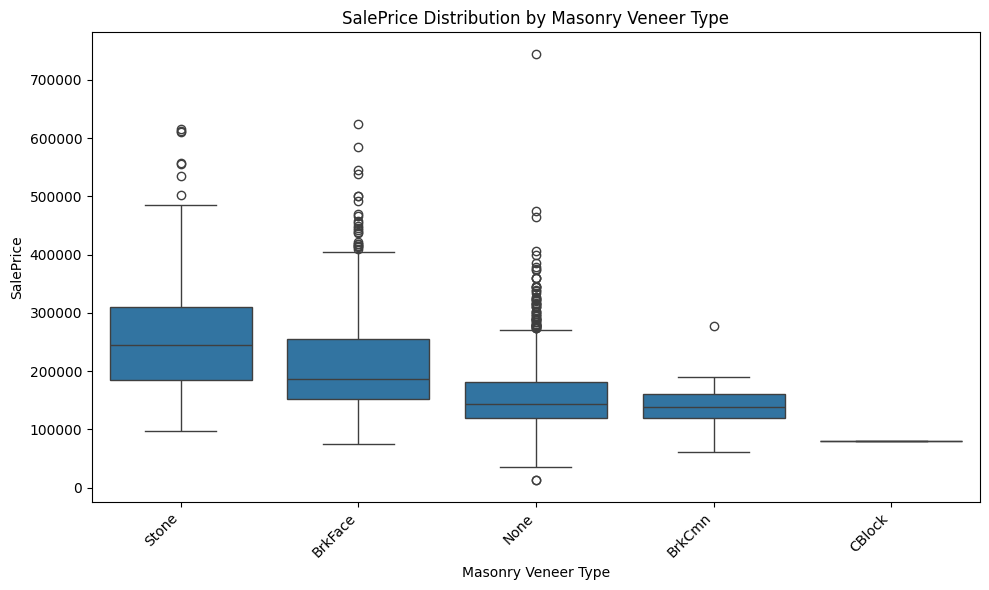

In [ ]:
# Ensure 'Mas Vnr Type' has no missing values, by filling NaN with 'None' as previously discussed.
hclean['Mas Vnr Type'] = hclean['Mas Vnr Type'].fillna('None')

# Calculate the mean and median SalePrice for each Mas Vnr Type
# Calculate the mean, median, and count of SalePrice for each Mas Vnr Type
mas_vnr_type_sales_summary = hclean.groupby('Mas Vnr Type')['SalePrice'].agg(['mean', 'median', 'count']).sort_values(by='median', ascending=False)

print("Mean and Median SalePrice by Mas Vnr Type:")
print(mas_vnr_type_sales_summary)

# Create a box plot to visualize the influence of 'Mas Vnr Type' on 'SalePrice'
plt.figure(figsize=(10, 6))
sns.boxplot(x='Mas Vnr Type', y='SalePrice', data=hclean, order=mas_vnr_type_sales_summary.index)
plt.title('SalePrice Distribution by Masonry Veneer Type')
plt.xlabel('Masonry Veneer Type')
plt.ylabel('SalePrice')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('mas_vnr_type_saleprice_boxplot.png')

In [ ]:
mas_vnr_type_counts = hclean['Mas Vnr Type'].value_counts()

print("Count of each unique variable in 'Mas Vnr Type' column:")
print(mas_vnr_type_counts)

Count of each unique variable in 'Mas Vnr Type' column:
Mas Vnr Type
None       1607
BrkFace     782
Stone       224
BrkCmn       23
CBlock        1
Name: count, dtype: int64


Since Nans have been imputed to display 'None'and the total of BrkFace and Stone is 1,000 homes, we can infer that homes with BrkFace and Stone are strongly correlated to a higher than average sale price. That means these features should stay in our predicitve model, since Masonry Veneer Type is an important factor influencing property sales prices.

In [ ]:
# Five columns from our set of 81 show that they include nulls. The question now is whether to "impute" values or to remove them outright.
# A follow up questions is whether they include Naans! We'll look at that after this step.

## Data Cleaning


## Exploratory Data Analysis


In [ ]:
# We want to establish a baseline first using features that are numerical, continuous, and don't have nulls.
# floats= 11 (none have nulls)
# Remove the rows that have the handful or Null values (from the float items).
# Easiest Baseline
# Take the 10 Floats, run through correlations matrix
# Helps you chose of the 10 floats, what you would select in your regression model.
# Establish baseline firs. Don't know how good your feature selection is until you have a baseline

## Processing


## Data Visualization/Communication of Results
